# 4. Implementing Matrix Factorization


### (a) Image Reconstruction

## **Objective 1**  
Reconstruct an image with missing pixel values using **Gradient Descent**. Perform the following two cases:  
1. A rectangular block of size 30×30 is missing.  
2. A random subset of 900 (30×30) pixels is missing.  

Tasks:  
- Select an appropriate rank `r`.  
- Run Gradient Descent until convergence.  
- Plot:  
  - The selected missing regions,  
  - The original image,  
  - The reconstructed image.  
- Compute:  
  - **RMSE** (predicted vs ground truth),  
  - **Peak SNR**.  


Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import torchvision

Device Set Up

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif torch.backends.mps.is_available():  # For Mac GPUs
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Working on device:", device)

Working on device: cpu


Setting the Random Seed

Setting a random seed ensures reproducibility by making all random operations—like matrix initialization and pixel masking—produce the same results every time. This allows consistent, verifiable experiments

In [3]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

Loading the Image

Colored image shape (C,H,W): torch.Size([3, 337, 600])
Min pixel value: 0.0
Max pixel value: 1.0


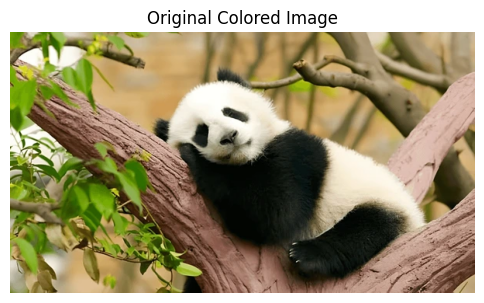

In [4]:
def normalize_image(image_tensor):
    return image_tensor.float() / 255.0


color_img = torchvision.io.read_image(r'C:\Users\Parth Dembla\Downloads\Machine Learning\ES---335-ML-Assignment-2\Task 4\panda.jpg')  # shape: [C, H, W]
color_img = normalize_image(color_img)
print("Colored image shape (C,H,W):", color_img.shape)
print("Min pixel value:", color_img.min().item())
print("Max pixel value:", color_img.max().item())

# Display colored image
plt.figure(figsize=(6,6))
plt.imshow(color_img.permute(1,2,0))  # convert [C,H,W] -> [H,W,C] for matplotlib
plt.title("Original Colored Image")
plt.axis('off')
plt.show()

Converting to Grayscale

Grayscale image shape: torch.Size([337, 600])


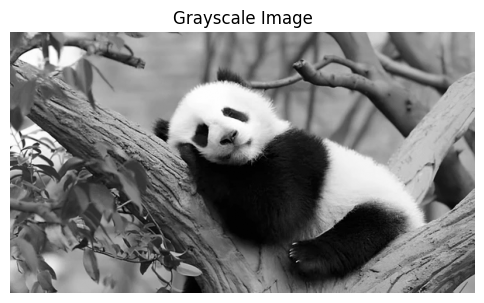

In [5]:
gray_img = color_img.mean(dim=0)  # average over channel dimension -> [H,W]
print("Grayscale image shape:", gray_img.shape)

plt.figure(figsize=(6,6))
plt.imshow(gray_img, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

# Convert to torch tensor for reconstruction
X = gray_img.clone()  # [H,W] tensor now it is ready for operations like matrix factorization

Move the Image tensor to device using .to(device) argument

In [6]:
X = X.to(device)

Defining Low Rank Reconstruction Function (Matrix Factorization)

In [13]:
def low_rank_reconstruction(X, mask, rank, lr, num_iters):
    """Function which does matrix factorization ; the arguments are:

    X = image tensor of the grayscale image [H,W]; it contains known pixel values
    mask = A tensor [H, W] with 1 for known pixels and 0 for missing pixels. This ensures we only calculate the loss on known pixels.
    r = The low-rank r of the factorization. X ≈ W @ H. Choosing r smaller than min(H, W) enforces a low-rank constraint that helps fill missing pixels using redundancy in the image.
    lr Learning rate for gradient descent. Controls how big each step is when updating W and H.
    Number of Iterations
    """
    
    m, n = X.shape
    W = torch.randn(m, rank, device=device, requires_grad=True)
    H = torch.randn(rank, n, device=device, requires_grad=True)
    
    optimizer = optim.Adam([W, H], lr=lr)
    losses = []
    
    print("--- Starting Gradient Descent ---")
    for it in range(num_iters):
        optimizer.zero_grad()
        X_hat = torch.mm(W, H)
        loss = ((X_hat - X) * mask).pow(2).sum()
        loss.backward()
        optimizer.step()
        
        # Store loss at each iteration
        losses.append(loss.item())
        
        
        if it % 5000== 0 or it == num_iters-1:
            print(f"GD Iteration {it:5d}, Loss={loss.item():.6f}")
            
    print("--- Gradient Descent Finished ---\n")


    plt.figure(figsize=(3,2))
    plt.plot(losses, label='Training Loss')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('Loss vs Iteration (Gradient Descent)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return torch.mm(W, H).detach(), losses

Metrics Calculation Function

In [14]:
def compute_metrics(X_true, X_pred):
    """Compute RMSE and PSNR over the entire image"""
    mse = ((X_true - X_pred).pow(2)).mean()
    rmse = torch.sqrt(mse).item()
    psnr = 20 * torch.log10(1.0 / torch.sqrt(mse)).item()
    return rmse, psnr

**case(i)**: Reconstructing the image for a rectangular block of 30X30 is assumed missing from the image.

Here, a mask is created to simulate missing pixels in the image. torch.ones_like(X) makes a mask of all ones (meaning all pixels are initially known). Then, a 30×30 block starting at (50,50) is set to zeros, marking those pixels as missing. Finally, multiplying X * block_mask sets the pixel values in that block to zero (hidden), while keeping the rest unchanged. This way, the algorithm knows which pixels are observed (1) and which are missing (0).

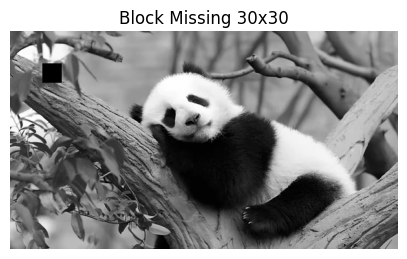


=== Reconstruction for Rank = 5 ===
--- Starting Gradient Descent ---
GD Iteration     0, Loss=1079704.000000
GD Iteration  5000, Loss=3643.489746
GD Iteration  9999, Loss=3575.664307
--- Gradient Descent Finished ---



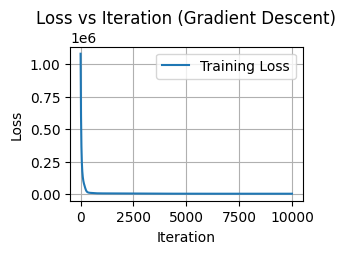

RMSE=0.133685, PSNR=17.48 dB

=== Reconstruction for Rank = 10 ===
--- Starting Gradient Descent ---
GD Iteration     0, Loss=1965379.750000
GD Iteration  5000, Loss=2720.427734
GD Iteration  9999, Loss=2130.035889
--- Gradient Descent Finished ---



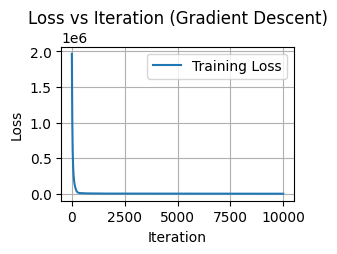

RMSE=0.104236, PSNR=19.64 dB

=== Reconstruction for Rank = 50 ===
--- Starting Gradient Descent ---
GD Iteration     0, Loss=10033895.000000
GD Iteration  5000, Loss=1409.938110
GD Iteration  9999, Loss=628.974976
--- Gradient Descent Finished ---



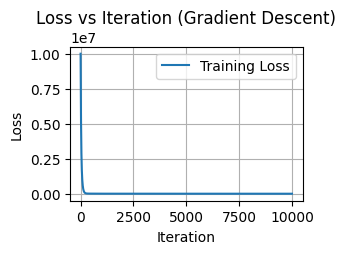

RMSE=0.073061, PSNR=22.73 dB

=== Reconstruction for Rank = 80 ===
--- Starting Gradient Descent ---
GD Iteration     0, Loss=15848509.000000
GD Iteration  5000, Loss=1092.930420
GD Iteration  9999, Loss=455.400146
--- Gradient Descent Finished ---



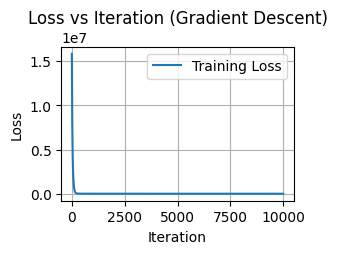

RMSE=0.095040, PSNR=20.44 dB


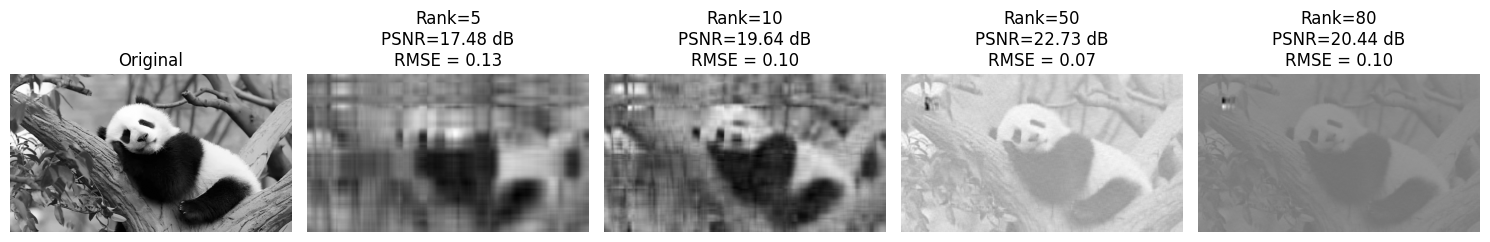

In [17]:
block_mask = torch.ones_like(X)
block_size = 30
start_row, start_col = 50, 50
block_mask[start_row:start_row+block_size, start_col:start_col+block_size] = 0
X_block_missing = X * block_mask


plt.figure(figsize=(5,5))
plt.imshow(X_block_missing.cpu(), cmap='gray')
plt.title("Block Missing 30x30")
plt.axis('off')
plt.show()


ranks = [5, 10, 50, 80]
results = {}

for r in ranks:
    print(f"\n=== Reconstruction for Rank = {r} ===")
    X_block_rec, losses = low_rank_reconstruction(X, block_mask, rank=r, lr=0.01, num_iters=10000)
    
    # Compute metrics
    rmse_block, psnr_block = compute_metrics(X, X_block_rec)
    results[r] = (X_block_rec, rmse_block, psnr_block)
    print(f"RMSE={rmse_block:.6f}, PSNR={psnr_block:.2f} dB")


plt.figure(figsize=(15,6))
plt.subplot(1, len(ranks)+1, 1)
plt.imshow(X.cpu(), cmap='gray')
plt.title("Original")
plt.axis('off')

for i, r in enumerate(ranks):
    plt.subplot(1, len(ranks)+1, i+2)
    plt.imshow(results[r][0].cpu(), cmap='gray')
    plt.title(f"Rank={r}\nPSNR={results[r][2]:.2f} dB\nRMSE = {results[r][1]:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()


**case(ii)**: Reconstructing the image for a random subset of 900 (30X30) pixels is missing from the image.

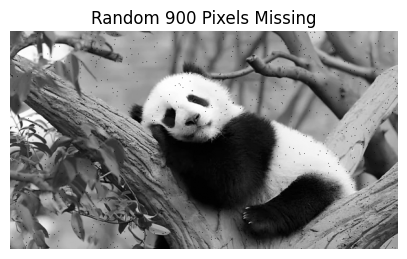


=== Reconstruction for Rank = 5 ===
--- Starting Gradient Descent ---
GD Iteration     0, Loss=1077424.750000
GD Iteration  5000, Loss=3603.777832
GD Iteration  9999, Loss=3582.141602
--- Gradient Descent Finished ---



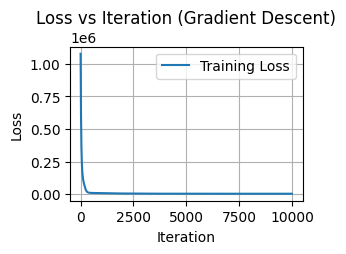

RMSE=0.133401, PSNR=17.50 dB

=== Reconstruction for Rank = 10 ===
--- Starting Gradient Descent ---
GD Iteration     0, Loss=2037858.500000
GD Iteration  5000, Loss=2671.193604
GD Iteration  9999, Loss=2137.502197
--- Gradient Descent Finished ---



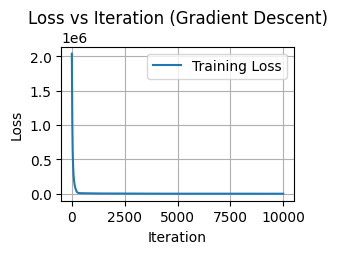

RMSE=0.103053, PSNR=19.74 dB

=== Reconstruction for Rank = 50 ===
--- Starting Gradient Descent ---
GD Iteration     0, Loss=9999047.000000
GD Iteration  5000, Loss=1426.002197
GD Iteration  9999, Loss=633.227112
--- Gradient Descent Finished ---



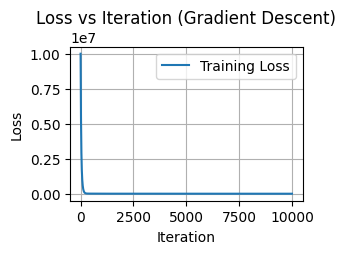

RMSE=0.056131, PSNR=25.02 dB

=== Reconstruction for Rank = 80 ===
--- Starting Gradient Descent ---
GD Iteration     0, Loss=15901726.000000
GD Iteration  5000, Loss=1119.501099
GD Iteration  9999, Loss=454.187592
--- Gradient Descent Finished ---



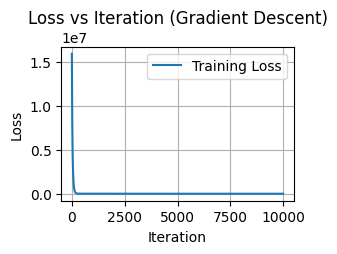

RMSE=0.047623, PSNR=26.44 dB


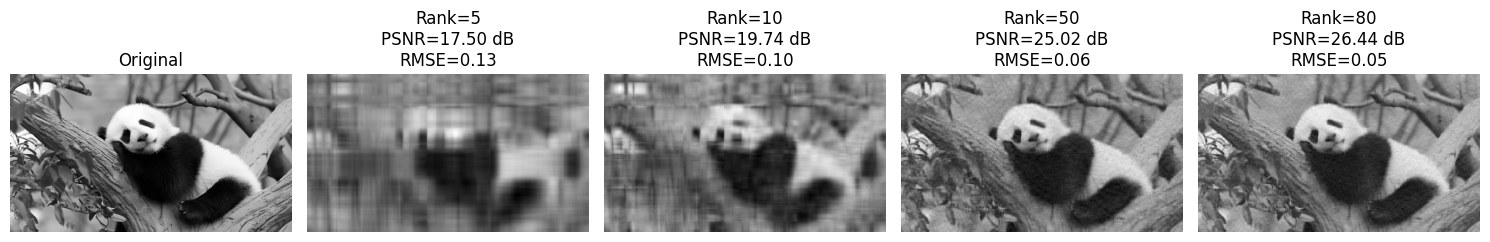


=== Summary (Random Missing) ===
Rank=  5 | RMSE=0.133401 | PSNR=17.50 dB
Rank= 10 | RMSE=0.103053 | PSNR=19.74 dB
Rank= 50 | RMSE=0.056131 | PSNR=25.02 dB
Rank= 80 | RMSE=0.047623 | PSNR=26.44 dB


In [ ]:
random_mask = torch.ones_like(X)
num_missing = 900
indices = torch.randperm(X.numel())[:num_missing]
random_mask.view(-1)[indices] = 0
X_random_missing = X * random_mask


plt.figure(figsize=(5,5))
plt.imshow(X_random_missing.cpu(), cmap='gray')
plt.title("Random 900 Pixels Missing")
plt.axis('off')
plt.show()


ranks = [5, 10, 50, 80]
random_results = {}

for r in ranks:
    print(f"\n=== Reconstruction for Rank = {r} ===")
    X_random_rec, losses = low_rank_reconstruction(X, random_mask, rank=r, lr=0.01, num_iters=10000)
    
    # Compute metrics
    rmse_random, psnr_random = compute_metrics(X, X_random_rec)
    random_results[r] = (X_random_rec, rmse_random, psnr_random)
    print(f"RMSE={rmse_random:.6f}, PSNR={psnr_random:.2f} dB")


plt.figure(figsize=(15,6))
plt.subplot(1, len(ranks)+1, 1)
plt.imshow(X.cpu(), cmap='gray')
plt.title("Original")
plt.axis('off')

for i, r in enumerate(ranks):
    plt.subplot(1, len(ranks)+1, i+2)
    plt.imshow(random_results[r][0].cpu(), cmap='gray')
    plt.title(f"Rank={r}\nPSNR={random_results[r][2]:.2f} dB\nRMSE={random_results[r][1]:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()


print("\n=== Summary (Random Missing) ===")
for r, (_, rmse, psnr) in random_results.items():
    print(f"Rank={r:3d} | RMSE={rmse:.6f} | PSNR={psnr:.2f} dB")


Now as the factorization is done for Black and white which has 1 channel , we can extend the same algorithm to colored image , In the color image case, the input has three channels (R, G, B). Since our low-rank reconstruction method works on 2D matrices, we apply it independently to each channel. That means we treat the red, green, and blue layers as separate grayscale images, reconstruct the missing regions in each one using matrix factorization with gradient descent, and then stack the channels back together to form the final RGB image.

Loading the Image

In [19]:
def normalize_image(image_tensor):
    return image_tensor.float() / 255.0

color_img = torchvision.io.read_image(r'C:\Users\Parth Dembla\Downloads\Machine Learning\ES---335-ML-Assignment-2\Task 4\panda.jpg') 
color_img = normalize_image(color_img).to(device)

print("Image shape:", color_img.shape)  

Image shape: torch.Size([3, 337, 600])


Function for Reconstruction and computing metrics

In [21]:
def low_rank_reconstruction(X, mask, rank, lr, num_iters):
    """Function which does matrix factorization ; the arguments are:

    X = image tensor of the grayscale image [H,W]; it contains known pixel values
    mask = A tensor [H, W] with 1 for known pixels and 0 for missing pixels. This ensures we only calculate the loss on known pixels.
    r = The low-rank r of the factorization. X ≈ W @ H. Choosing r smaller than min(H, W) enforces a low-rank constraint that helps fill missing pixels using redundancy in the image.
    lr Learning rate for gradient descent. Controls how big each step is when updating W and H.
    Number of Iterations
    """
    
    m, n = X.shape
    W = torch.randn(m, rank, device=device, requires_grad=True)
    H = torch.randn(rank, n, device=device, requires_grad=True)
    
    optimizer = optim.Adam([W, H], lr=lr)
    losses = []
    
    print("--- Starting Gradient Descent ---")
    for it in range(num_iters):
        optimizer.zero_grad()
        X_hat = torch.mm(W, H)
        loss = ((X_hat - X) * mask).pow(2).sum()
        loss.backward()
        optimizer.step()
        
        # Store loss at each iteration
        losses.append(loss.item())
        
        
        if it % 5000== 0 or it == num_iters-1:
            print(f"GD Iteration {it:5d}, Loss={loss.item():.6f}")
            
    print("--- Gradient Descent Finished ---\n")

    return torch.mm(W, H).detach(), losses


def compute_metrics(X_true, X_pred):
    """Compute RMSE and PSNR over the entire image"""
    mse = ((X_true - X_pred).pow(2)).mean()
    rmse = torch.sqrt(mse).item()
    psnr = 20 * torch.log10(1.0 / torch.sqrt(mse)).item()
    return rmse, psnr

**case(i)**: Reconstructing the image for a rectangular block of 30X30 is assumed missing from the image.


=== Reconstruction for Rank = 5 ===
--- Starting Gradient Descent ---
GD Iteration     0, Loss=999523.000000
GD Iteration  5000, Loss=4163.687500
GD Iteration  9999, Loss=4018.766357
--- Gradient Descent Finished ---

--- Starting Gradient Descent ---
GD Iteration     0, Loss=1084524.125000
GD Iteration  5000, Loss=3517.571045
GD Iteration  9999, Loss=3444.103516
--- Gradient Descent Finished ---

--- Starting Gradient Descent ---
GD Iteration     0, Loss=1003647.625000
GD Iteration  5000, Loss=3905.986816
GD Iteration  9999, Loss=3875.785645
--- Gradient Descent Finished ---

RMSE=0.137502, PSNR=17.23 dB

=== Reconstruction for Rank = 10 ===
--- Starting Gradient Descent ---
GD Iteration     0, Loss=2011829.750000
GD Iteration  5000, Loss=2995.095947
GD Iteration  9999, Loss=2429.874512
--- Gradient Descent Finished ---

--- Starting Gradient Descent ---
GD Iteration     0, Loss=2037429.000000
GD Iteration  5000, Loss=2596.466797
GD Iteration  9999, Loss=2039.395752
--- Gradient Desc

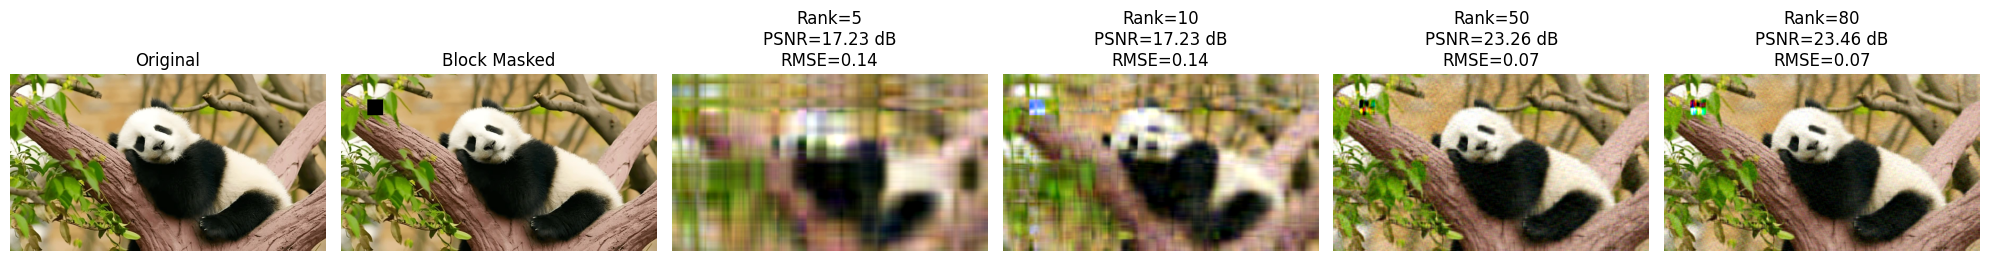

In [22]:
import torch
import matplotlib.pyplot as plt

# Image shape
C, H, W = color_img.shape

# Block mask
block_mask = torch.ones((H, W), device=device)
block_size = 30
start_row, start_col = 50, 50
block_mask[start_row:start_row+block_size, start_col:start_col+block_size] = 0

# Masked image
color_block_missing = color_img * block_mask.unsqueeze(0)


ranks = [5, 10, 50, 80]


results = {}

for rank in ranks:
    print(f"\n=== Reconstruction for Rank = {rank} ===")
    color_rec_block = []
    for c in range(C):
        X = color_img[c]
        rec, losses = low_rank_reconstruction(X, block_mask, rank=rank, lr=0.01, num_iters=10000)
        color_rec_block.append(rec)
    
 
    color_rec_block = torch.stack(color_rec_block, dim=0)
    
    
    rmse_block, psnr_block = compute_metrics(color_img, color_rec_block)
    results[rank] = (color_rec_block, rmse_block, psnr_block)
    
    print(f"RMSE={rmse_block:.6f}, PSNR={psnr_block:.2f} dB")


plt.figure(figsize=(20,5))

plt.subplot(1, len(ranks)+2, 1)
plt.imshow(color_img.permute(1,2,0).cpu())
plt.title("Original")
plt.axis('off')


plt.subplot(1, len(ranks)+2, 2)
plt.imshow(color_block_missing.permute(1,2,0).cpu())
plt.title("Block Masked")
plt.axis('off')


for i, rank in enumerate(ranks):
    rec, rmse, psnr = results[rank]
    plt.subplot(1, len(ranks)+2, i+3)
    plt.imshow(rec.permute(1,2,0).cpu().clamp(0,1))
    plt.title(f"Rank={rank}\nPSNR={psnr:.2f} dB\nRMSE={rmse:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()


**case(ii)**: Reconstructing the image for a random subset of 900 (30X30) pixels is missing from the image.


=== Reconstruction for Rank = 5 ===
--- Starting Gradient Descent ---
GD Iteration     0, Loss=1076602.500000
GD Iteration  5000, Loss=4167.182617
GD Iteration  9999, Loss=4030.567627
--- Gradient Descent Finished ---

--- Starting Gradient Descent ---
GD Iteration     0, Loss=1107006.250000
GD Iteration  5000, Loss=3573.429932
GD Iteration  9999, Loss=3441.622559
--- Gradient Descent Finished ---

--- Starting Gradient Descent ---
GD Iteration     0, Loss=1006197.437500
GD Iteration  5000, Loss=3915.312256
GD Iteration  9999, Loss=3892.446045
--- Gradient Descent Finished ---

RMSE=0.137210, PSNR=17.25 dB

=== Reconstruction for Rank = 10 ===
--- Starting Gradient Descent ---
GD Iteration     0, Loss=2063602.250000
GD Iteration  5000, Loss=2959.559082
GD Iteration  9999, Loss=2432.824463
--- Gradient Descent Finished ---

--- Starting Gradient Descent ---
GD Iteration     0, Loss=2126537.500000
GD Iteration  5000, Loss=2619.753174
GD Iteration  9999, Loss=2049.419434
--- Gradient Des

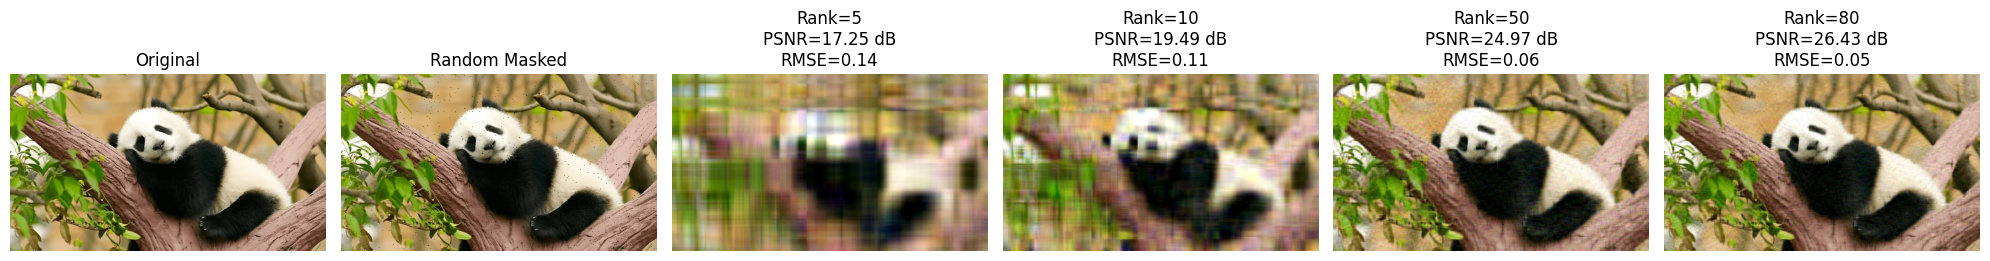

In [23]:
import torch
import matplotlib.pyplot as plt


C, H, W = color_img.shape


num_missing = 900
indices = torch.randperm(H*W, device=device)[:num_missing]
random_mask = torch.ones((H, W), device=device)
random_mask.view(-1)[indices] = 0


color_random_missing = color_img * random_mask.unsqueeze(0)

# Ranks to try
ranks = [5, 10, 50, 80]

random_results = {}

for rank in ranks:
    print(f"\n=== Reconstruction for Rank = {rank} ===")
    color_rec_random = []
    for c in range(C):
        X = color_img[c]
        rec, losses = low_rank_reconstruction(X, random_mask, rank=rank, lr=0.01, num_iters=10000)
        color_rec_random.append(rec)
    

    color_rec_random = torch.stack(color_rec_random, dim=0)
    
    rmse_random, psnr_random = compute_metrics(color_img, color_rec_random)
    random_results[rank] = (color_rec_random, rmse_random, psnr_random)
    
    print(f"RMSE={rmse_random:.6f}, PSNR={psnr_random:.2f} dB")

plt.figure(figsize=(20,5))


plt.subplot(1, len(ranks)+2, 1)
plt.imshow(color_img.permute(1,2,0).cpu())
plt.title("Original")
plt.axis('off')


plt.subplot(1, len(ranks)+2, 2)
plt.imshow(color_random_missing.permute(1,2,0).cpu())
plt.title("Random Masked")
plt.axis('off')

# Reconstructions for each rank
for i, rank in enumerate(ranks):
    rec, rmse, psnr = random_results[rank]
    plt.subplot(1, len(ranks)+2, i+3)
    plt.imshow(rec.permute(1,2,0).cpu().clamp(0,1))
    plt.title(f"Rank={rank}\nPSNR={psnr:.2f} dB\nRMSE={rmse:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In low-rank matrix reconstruction, the rank 
r determines the expressive capacity of the factorization 
𝑋≈𝑊⋅𝐻
X≈W⋅H. A smaller rank enforces a simpler model, which can capture only the most dominant patterns in the image but fails to recover fine details, especially in large missing regions such as a 30×30 block. This often results in blurry or inaccurate reconstructions. Increasing the rank allows the model to represent more complex structures and textures, improving the reconstruction quality of missing pixels. However, a very high rank can lead to overfitting and increased computational cost. In practice, the rank is chosen as a trade-off: moderate values are sufficient for randomly missing pixels, while larger ranks are beneficial for reconstructing contiguous missing blocks where local information is unavailable. Adjusting the rank alongside the number of iterations and learning rate allows the gradient descent optimization to better approximate the high-resolution image.

It can also be observed that Low-rank reconstruction works better for random missing pixels because the known pixels are spread across the image, giving the model context everywhere to infer missing values. In contrast, a missing block leaves a large region with no local information, so the model must guess using only global patterns, resulting in blurry and less accurate reconstruction.

## **Objective 2**  
Reconstruct the same images (Case 1 and 2) using **Alternating Least Squares (ALS)** instead of Gradient Descent.  

Tasks:  
- Write your own ALS function using [`torch.linalg.lstsq`](https://pytorch.org/docs/stable/generated/torch.linalg.lstsq.html).  
- Compare reconstructed results and metrics with the Gradient Descent approach.  


Loading the Image

In [24]:
def normalize_image(image_tensor):
    return image_tensor.float() / 255.0

color_img = torchvision.io.read_image(r'C:\Users\Parth Dembla\Downloads\Machine Learning\ES---335-ML-Assignment-2\Task 4\panda.jpg') 
color_img = normalize_image(color_img).to(device)

print("Image shape:", color_img.shape)  

Image shape: torch.Size([3, 337, 600])


Defining the Low rank Reconstruction Fuction using ALS Method

In [26]:
def low_rank_reconstruction_als(X, mask, rank, num_iters):
    """
    X     : [H,W] grayscale image (or one channel of colored image)
    mask  : [H,W] binary tensor: 1 for known pixels, 0 for missing
    rank  : rank for low-rank factorization
    num_iters : number of ALS iterations
    """
    m, n = X.shape
    device = X.device
    
    W = torch.randn(m, rank, device=device)
    H = torch.randn(rank, n, device=device)
    
    mask = mask.to(dtype=X.dtype)
    losses = []
    
    print("--- Starting Alternating Least Squares ---")
    for it in range(num_iters):
        # Update W,Fix H
        for i in range(m):
            known_idx = mask[i, :] == 1
            if known_idx.sum() == 0: continue
            H_sub = H[:, known_idx]
            X_sub = X[i, known_idx]
            w_i, _ = torch.linalg.lstsq(H_sub.T, X_sub.T)[:2]
            W[i, :] = w_i.T
            
        # Update H, Fix W
        for j in range(n):
            known_idx = mask[:, j] == 1
            if known_idx.sum() == 0: continue
            W_sub = W[known_idx, :]
            X_sub = X[known_idx, j]
            h_j, _ = torch.linalg.lstsq(W_sub, X_sub)[:2]
            H[:, j] = h_j.squeeze()

        #  printing the loss after each full iteration
        X_hat = torch.mm(W, H)
        loss = ((X_hat - X) * mask).pow(2).sum()
        losses.append(loss.item())
        if it % 10== 0 or it == num_iters-1:
            print(f"ALS Iteration {it:2d}, Loss={loss.item():.6f}")
        
    print("--- ALS Finished ---\n")
    return torch.mm(W, H), losses

**case(i)**: Reconstructing the image for a rectangular block of 30X30 is assumed missing from the image.

--- Starting Alternating Least Squares ---
ALS Iteration  0, Loss=5425.809082
ALS Iteration 10, Loss=2426.958252
ALS Iteration 20, Loss=2426.812988
ALS Iteration 29, Loss=2426.802979
--- ALS Finished ---

--- Starting Alternating Least Squares ---
ALS Iteration  0, Loss=5563.414062
ALS Iteration 10, Loss=2039.096924
ALS Iteration 20, Loss=2038.976318
ALS Iteration 29, Loss=2038.975952
--- ALS Finished ---

--- Starting Alternating Least Squares ---
ALS Iteration  0, Loss=4278.270020
ALS Iteration 10, Loss=2257.357178
ALS Iteration 20, Loss=2251.531738
ALS Iteration 29, Loss=2247.958496
--- ALS Finished ---

Rank=10: RMSE=0.113084, PSNR=18.93 dB
--- Starting Alternating Least Squares ---
ALS Iteration  0, Loss=2047.457031
ALS Iteration 10, Loss=846.422607
ALS Iteration 20, Loss=844.177368
ALS Iteration 29, Loss=843.394653
--- ALS Finished ---

--- Starting Alternating Least Squares ---
ALS Iteration  0, Loss=1879.364014
ALS Iteration 10, Loss=774.386414
ALS Iteration 20, Loss=771.562012

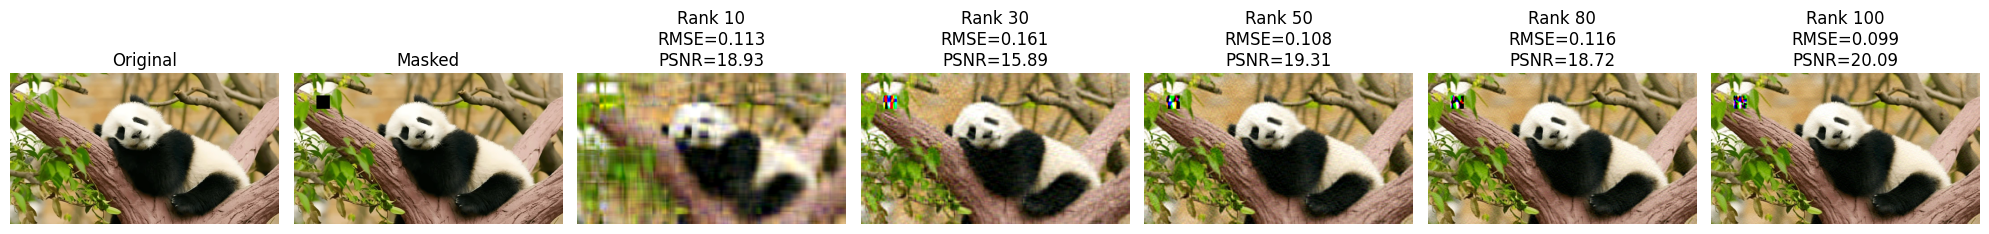

In [32]:

ranks = [10, 30, 50, 80, 100]

rec_images = []
metrics = []

for rank in ranks:
    color_rec = []
    for c in range(C):
        X = color_img[c]
        rec = low_rank_reconstruction_als(X, block_mask, rank=rank, num_iters=30)
        rec = rec[0]
        color_rec.append(rec)
    color_rec_block_als = torch.stack(color_rec, dim=0)
    rec_images.append(color_rec_block_als)

    rmse, psnr = compute_metrics(color_img, color_rec_block_als)
    metrics.append((rmse, psnr))
    print(f"Rank={rank}: RMSE={rmse:.6f}, PSNR={psnr:.2f} dB")

# Plot the results
plt.figure(figsize=(20, 4))
plt.subplot(1, len(ranks)+2, 1)
plt.imshow(color_img.permute(1,2,0).cpu())
plt.title("Original")
plt.axis('off')

plt.subplot(1, len(ranks)+2, 2)
plt.imshow(color_block_missing.permute(1,2,0).cpu())
plt.title("Masked")
plt.axis('off')

for i, rank in enumerate(ranks):
    plt.subplot(1, len(ranks)+2, i+3)
    plt.imshow(rec_images[i].permute(1,2,0).cpu().clamp(0,1))
    plt.title(f"Rank {rank}\nRMSE={metrics[i][0]:.3f}\nPSNR={metrics[i][1]:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()


**case(ii)**: Reconstructing the image for a random subset of 900 (30X30) pixels is missing from the image.

--- Starting Alternating Least Squares ---
ALS Iteration  0, Loss=5741.435059
ALS Iteration 10, Loss=2431.903320
ALS Iteration 20, Loss=2430.080078
ALS Iteration 29, Loss=2430.077148
--- ALS Finished ---

--- Starting Alternating Least Squares ---
ALS Iteration  0, Loss=4285.063965
ALS Iteration 10, Loss=2041.715210
ALS Iteration 20, Loss=2041.694702
ALS Iteration 29, Loss=2041.694580
--- ALS Finished ---

--- Starting Alternating Least Squares ---
ALS Iteration  0, Loss=4576.309082
ALS Iteration 10, Loss=2312.552734
ALS Iteration 20, Loss=2305.788086
ALS Iteration 29, Loss=2302.958984
--- ALS Finished ---

Rank=10: RMSE=0.105977, PSNR=19.50 dB
--- Starting Alternating Least Squares ---
ALS Iteration  0, Loss=2182.068848
ALS Iteration 10, Loss=861.660034
ALS Iteration 20, Loss=859.301514
ALS Iteration 29, Loss=858.820740
--- ALS Finished ---

--- Starting Alternating Least Squares ---
ALS Iteration  0, Loss=1817.719116
ALS Iteration 10, Loss=791.119141
ALS Iteration 20, Loss=789.558044

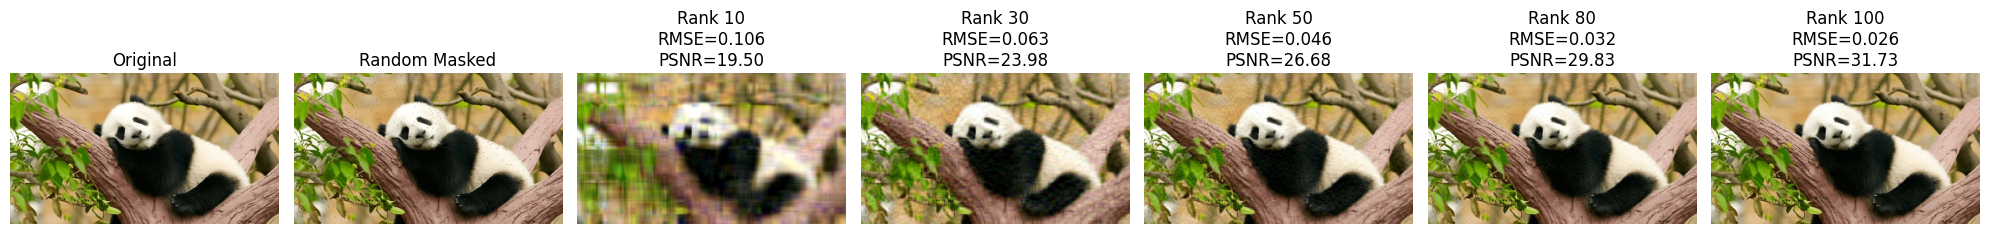

In [37]:

ranks = [10, 30, 50, 80, 100]


num_missing = 900

rec_images_random = []
metrics_random = []

for rank in ranks:
    
    random_mask = torch.ones((H, W), device=device)
    indices = torch.randperm(H*W, device=device)[:num_missing]
    random_mask.view(-1)[indices] = 0


    color_random_missing = color_img * random_mask.unsqueeze(0)

   
    color_rec = []
    for c in range(C):
        X = color_img[c]
        rec = low_rank_reconstruction_als(X, random_mask, rank=rank, num_iters=30)
        rec = rec[0]
        color_rec.append(rec)
    color_rec_random_als = torch.stack(color_rec, dim=0)
    rec_images_random.append(color_rec_random_als)

  
    rmse, psnr = compute_metrics(color_img, color_rec_random_als)
    metrics_random.append((rmse, psnr))
    print(f"Rank={rank}: RMSE={rmse:.6f}, PSNR={psnr:.2f} dB")

plt.figure(figsize=(20, 4))
plt.subplot(1, len(ranks)+2, 1)
plt.imshow(color_img.permute(1,2,0).cpu())
plt.title("Original")
plt.axis('off')

plt.subplot(1, len(ranks)+2, 2)
plt.imshow(color_random_missing.permute(1,2,0).cpu())
plt.title("Random Masked")
plt.axis('off')

for i, rank in enumerate(ranks):
    plt.subplot(1, len(ranks)+2, i+3)
    plt.imshow(rec_images_random[i].permute(1,2,0).cpu().clamp(0,1))
    plt.title(f"Rank {rank}\nRMSE={metrics_random[i][0]:.3f}\nPSNR={metrics_random[i][1]:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()


**Comparing the ALS and Gradient Descent Results**

Let's look at the convergence

--- Starting Gradient Descent ---
GD Iteration     0, Loss=10069678.000000
GD Iteration  5000, Loss=1501.140747
GD Iteration  9999, Loss=647.903442
--- Gradient Descent Finished ---

--- Starting Alternating Least Squares ---
ALS Iteration  0, Loss=1633.097900
ALS Iteration 10, Loss=450.364563
ALS Iteration 20, Loss=449.307861
ALS Iteration 29, Loss=449.144257
--- ALS Finished ---



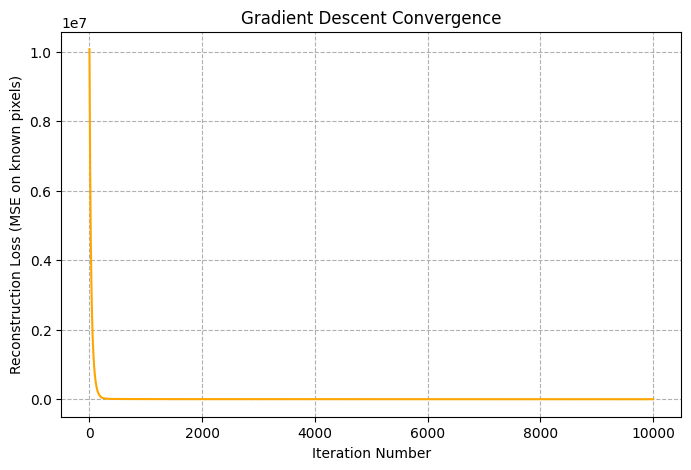

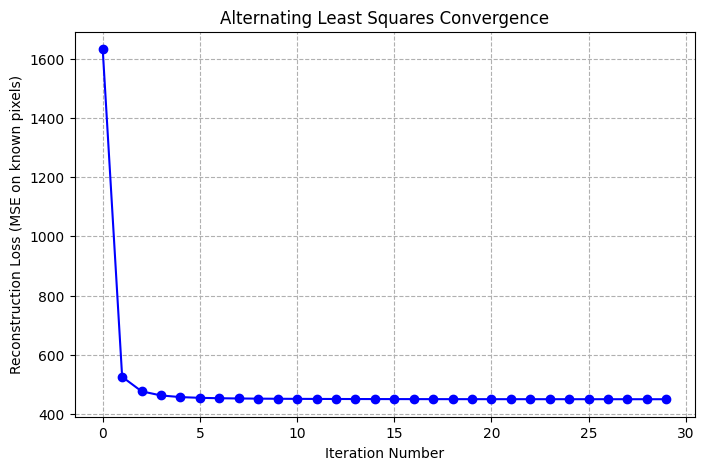

In [30]:
# using the first channel of the image as an example
X_channel_0 = color_img[0]
rank = 50 

# Run Gradient Descent and get loss history (using 2000 iterations for the example)
_, gd_losses = low_rank_reconstruction(
    X_channel_0, random_mask, rank=rank, lr=0.01, num_iters=10000
)

# Run ALS and get loss history
_, als_losses = low_rank_reconstruction_als(
    X_channel_0, random_mask, rank=rank, num_iters=30
)

# Gradient Descent plot 
plt.figure(figsize=(8, 5))
plt.plot(gd_losses, color='orange')
plt.title('Gradient Descent Convergence')
plt.xlabel('Iteration Number')
plt.ylabel('Reconstruction Loss (MSE on known pixels)')
plt.grid(True, which="both", ls="--")
plt.show()

# ALS plot
plt.figure(figsize=(8, 5))
plt.plot(als_losses, color='blue', marker='o')
plt.title('Alternating Least Squares Convergence')
plt.xlabel('Iteration Number')
plt.ylabel('Reconstruction Loss (MSE on known pixels)')
plt.grid(True, which="both", ls="--")
plt.show()


Now comparing RMSE and PSNR

In [38]:
import pandas as pd

results_data = []


rmse_block_gd, psnr_block_gd = compute_metrics(color_img, color_rec_block)
results_data.append({
    'Case': '30x30 Missing Block',
    'Method': 'Gradient Descent',
    'Rank': 80,
    'Iterations': 10000,
    'RMSE': f"{rmse_block_gd:.6f}",
    'PSNR (dB)': f"{psnr_block_gd:.2f}"
})

rmse_block_als, psnr_block_als = compute_metrics(color_img, color_rec_block_als)
results_data.append({
    'Case': '30x30 Missing Block',
    'Method': 'ALS',
    'Rank': 80,
    'Iterations': 30,
    'RMSE': f"{rmse_block_als:.6f}",
    'PSNR (dB)': f"{psnr_block_als:.2f}"
})

rmse_random_gd, psnr_random_gd = compute_metrics(color_img, color_rec_random)
results_data.append({
    'Case': 'Random 900 Missing Pixels',
    'Method': 'Gradient Descent',
    'Rank': 80,
    'Iterations': 10000,
    'RMSE': f"{rmse_random_gd:.6f}",
    'PSNR (dB)': f"{psnr_random_gd:.2f}"
})

rmse_random_als, psnr_random_als = compute_metrics(color_img, color_rec_random_als)
results_data.append({
    'Case': 'Random 900 Missing Pixels',
    'Method': 'ALS',
    'Rank': 80,
    'Iterations': 30,
    'RMSE': f"{rmse_random_als:.6f}",
    'PSNR (dB)': f"{psnr_random_als:.2f}"
})

# Create DataFrame
results_df = pd.DataFrame(results_data)

print("Comparison of Gradient Descent vs ALS (Rank 80)")
print(results_df.to_string(index=False))


Comparison of Gradient Descent vs ALS (Rank 80)
                     Case           Method  Rank  Iterations     RMSE PSNR (dB)
      30x30 Missing Block Gradient Descent    80       10000 0.067110     23.46
      30x30 Missing Block              ALS    80          30 0.099017     20.09
Random 900 Missing Pixels Gradient Descent    80       10000 0.047678     26.43
Random 900 Missing Pixels              ALS    80          30 0.025898     31.73


In the block-missing case, the Alternating Least Squares algorithm shows a higher RMSE and lower PSNR compared to Gradient Descent, indicating poorer reconstruction quality. However, for random missing pixels, the trend reverses ALS achieves lower RMSE and higher PSNR, showing better recovery performance. This suggests that ALS is more effective when missing data is randomly distributed, but struggles when large continuous regions are missing, likely due to less spatial information available for accurate reconstruction. Despite this, ALS consistently converges in far fewer iterations than Gradient Descent, demonstrating its efficiency and faster convergence rate. Overall, ALS is computationally more efficient, while Gradient Descent can perform better in structured missing cases where gradual optimization helps capture spatial dependencies.